<a href="https://colab.research.google.com/github/itsaryan207/Lead_scoring_analysis.ipynb/blob/main/Lead_scoring_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [7]:
# Generate synthetic CRM data
np.random.seed(42)
data_size = 1000
data = {
    'Lead_Source': np.random.choice(['Google', 'Organic', 'Reference', 'Social Media'], data_size),
    'Time_Spent_on_Website': np.random.randint(5, 60, data_size),
    'Pages_Per_Visit': np.random.uniform(1, 10, data_size),
    'Total_Visits': np.random.randint(1, 20, data_size),
    'Last_Activity': np.random.choice(['Email Opened', 'SMS Sent', 'Page Visited', 'Unreachable'], data_size),
    'Converted': np.random.randint(0, 2, data_size)
}

df = pd.DataFrame(data)

# Convert text to numbers (One-Hot Encoding)
df_final = pd.get_dummies(df, columns=['Lead_Source', 'Last_Activity'], drop_first=True)
df_final.head() # This displays the first 5 rows

,Time_Spent_on_Website,Pages_Per_Visit,Total_Visits,Converted,Lead_Source_Organic,Lead_Source_Reference,Lead_Source_Social Media,Last_Activity_Page Visited,Last_Activity_SMS Sent,Last_Activity_Unreachable
0,58,9.889502,14,0,False,True,False,True,False,False
1,21,4.849958,9,1,False,False,True,False,False,True
2,13,4.458940,8,0,False,False,False,True,False,False
3,37,7.116826,17,1,False,True,False,False,False,False
4,57,2.964285,2,1,False,True,False,False,False,False


In [8]:
# Split data into training (75%) and testing (25%)
X = df_final.drop('Converted', axis=1)
y = df_final['Converted']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=101)

# Initialize and Train Random Forest
model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
model.fit(X_train, y_train)

# Show results
predictions = model.predict(X_test)
print(f"Model Accuracy: {accuracy_score(y_test, predictions):.2%}")
print("\nDetailed Report:\n", classification_report(y_test, predictions))

Model Accuracy: 47.60%

Detailed Report:
               precision    recall  f1-score   support

           0       0.45      0.43      0.44       120
           1       0.50      0.52      0.51       130

    accuracy                           0.48       250
   macro avg       0.47      0.47      0.47       250
weighted avg       0.48      0.48      0.48       250



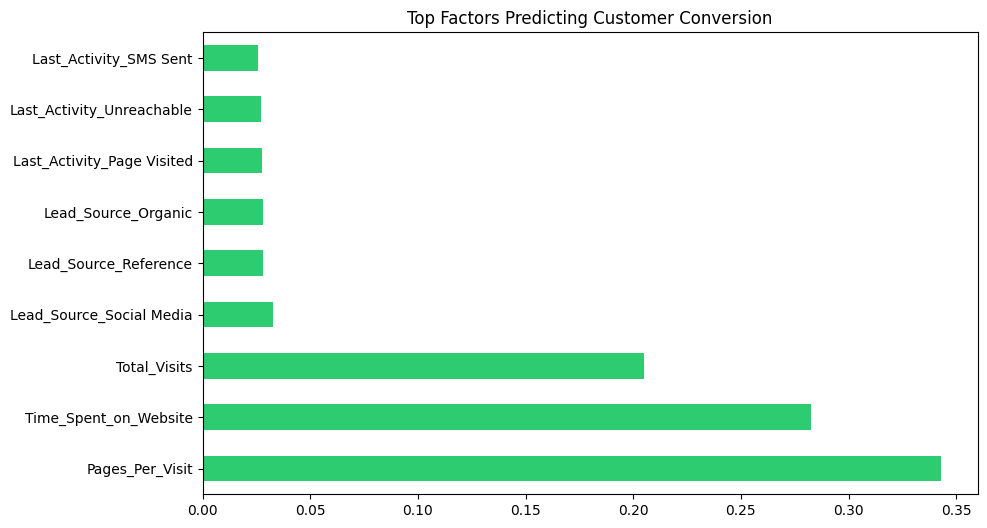

In [9]:
plt.figure(figsize=(10,6))
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh', color='#2ecc71')
plt.title('Top Factors Predicting Customer Conversion')
plt.show()

The current model uses synthetic data for demonstration. In a real-world scenario, i could improve accuracy by collecting more historical lead data and performing hyperparameter tuning.